In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics

In [2]:
data = pd.read_csv("car_evaluation.csv")
data

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


Now we need to add column name to our dataset

In [3]:
cols = ["Purchase","Maintenance","Doors","Capacity",
        "Luggage","Safety","Class"]

data.columns = cols
data

,Purchase,Maintenance,Doors,Capacity,Luggage,Safety,Class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Purchase     1727 non-null   str  
 1   Maintenance  1727 non-null   str  
 2   Doors        1727 non-null   str  
 3   Capacity     1727 non-null   str  
 4   Luggage      1727 non-null   str  
 5   Safety       1727 non-null   str  
 6   Class        1727 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


In [5]:
data.isnull().sum()

Purchase       0
Maintenance    0
Doors          0
Capacity       0
Luggage        0
Safety         0
Class          0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.head()

,Purchase,Maintenance,Doors,Capacity,Luggage,Safety,Class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [8]:
data.tail()

,Purchase,Maintenance,Doors,Capacity,Luggage,Safety,Class
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good
1726,low,low,5more,more,big,high,vgood


In [9]:
print(data["Purchase"].value_counts())

Purchase
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64


In [10]:
for i in data.columns:
    print(data[i].value_counts())
    print("-------------------")

Purchase
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
-------------------
Maintenance
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
-------------------
Doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
-------------------
Capacity
4       576
more    576
2       575
Name: count, dtype: int64
-------------------
Luggage
med      576
big      576
small    575
Name: count, dtype: int64
-------------------
Safety
med     576
high    576
low     575
Name: count, dtype: int64
-------------------
Class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64
-------------------


In [11]:
cat = [
    ["low","med","high","vhigh"],
    ["low","med","high","vhigh"],
    ["2","3","4","5more"],
    ["2","4","more"],
    ["small","med","big"],
    ["low","med","high"],
    ["unacc","acc","good","vgood"]
]

encoder = preprocessing.OrdinalEncoder(categories=cat)
data2 = encoder.fit_transform(data)
data2 = pd.DataFrame(data2,columns=cols).astype(int)
data2

,Purchase,Maintenance,Doors,Capacity,Luggage,Safety,Class
0,3,3,0,0,0,1,0
1,3,3,0,0,0,2,0
2,3,3,0,0,1,0,0
3,3,3,0,0,1,1,0
4,3,3,0,0,1,2,0
...,...,...,...,...,...,...,...
1722,0,0,3,2,1,1,2
1723,0,0,3,2,1,2,3
1724,0,0,3,2,2,0,0
1725,0,0,3,2,2,1,2


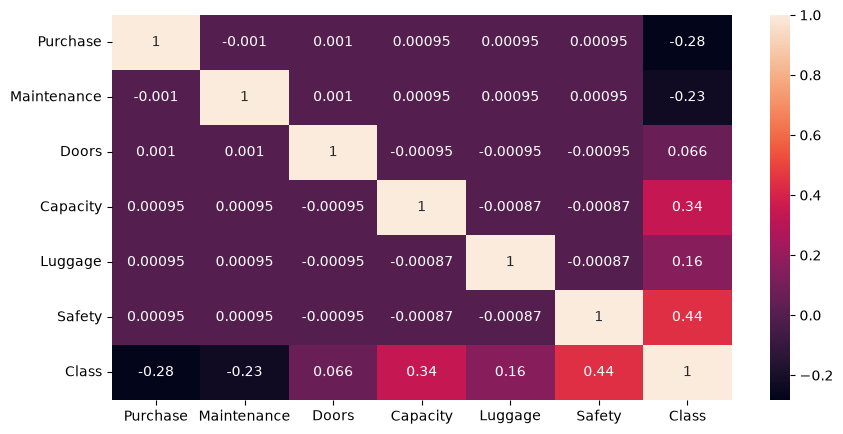

In [12]:
plt.figure(figsize=(10,5))
sns.heatmap(data2.corr(),annot=True)
plt.show()

In [13]:
x = data2.drop("Class",axis=1)
y = data2["Class"]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42,test_size=0.2)
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((1381, 6), (346, 6), (1381,), (346,))

In [15]:
x_train

,Purchase,Maintenance,Doors,Capacity,Luggage,Safety
107,3,2,0,0,0,0
900,1,3,1,1,0,1
1708,0,0,3,0,2,2
705,2,1,2,0,1,1
678,2,1,1,0,1,1
...,...,...,...,...,...,...
1130,1,1,1,2,2,0
1294,1,0,3,2,2,2
860,2,0,3,2,2,0
1459,0,2,2,0,0,2


In [16]:
x_train.iloc[0]

Purchase       3
Maintenance    2
Doors          0
Capacity       0
Luggage        0
Safety         0
Name: 107, dtype: int64

In [17]:
model_tree = tree.DecisionTreeClassifier()
model_tree.fit(x_train,y_train)
y_pishbini = model_tree.predict(x_test)
metrics.accuracy_score(y_test,y_pishbini)*100

96.53179190751445

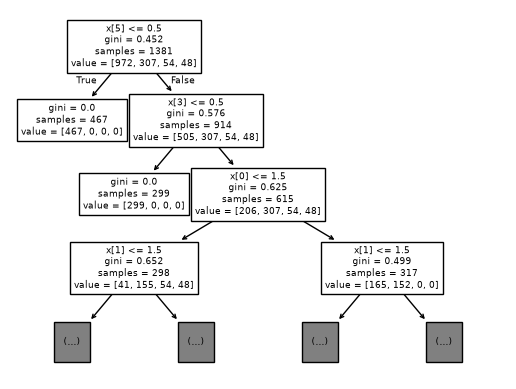

In [18]:
tree.plot_tree(model_tree, max_depth=3)
plt.show()

In [19]:
model_forest = ensemble.RandomForestClassifier(random_state=42)
model_forest.fit(x_train,y_train)
y_pishbini2 = model_forest.predict(x_test)
metrics.accuracy_score(y_test,y_pishbini2)*100

95.95375722543352